---
##### *DSAI3301 Data Analysis & Visualization - 5* 

## *Project #19* - **Medical Insurance Charges Determinants**
### Amanda Haddad - 60306436

##### *Research Question:* Which factors significantly influence medical insurance charges, and how large are their effects?
##### *Methodology:* Inferential Statistical Analysis
##### *Domain:* Healthcare & Insurance
##### *Dataset Link:* https://www.kaggle.com/datasets/mirichoi0218/insurance
---



### 1. Libraries & Dataset Setup
---

In [ ]:
# environment setup
!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn jupyter

In [3]:
# imports & dataset loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 2. Dataset Description
---

In [ ]:
# column data types
df.dtypes

# all approporiate, no conversions needed

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [ ]:
# statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
# rows and columns
df.shape

(1338, 7)

### 3. Data Cleaning
---

In [ ]:
# check for missing/null values
df.isnull().sum()

# no missing/null values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
# check for duplicates
df.duplicated().sum()

np.int64(1)

In [ ]:
# remove the 1 duplicate row found, then check shape
df = df.drop_duplicates()
df.shape       # Expected: (1337, 7)

(1337, 7)

In [ ]:
# categorical columns:
# check expected values (no typos or unexpected entries)
print(df['sex'].unique())      # Expected: ['male' 'female']
print(df['smoker'].unique())   # Expected: ['yes' 'no']
print(df['region'].unique())   # Expected: 4 regions

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


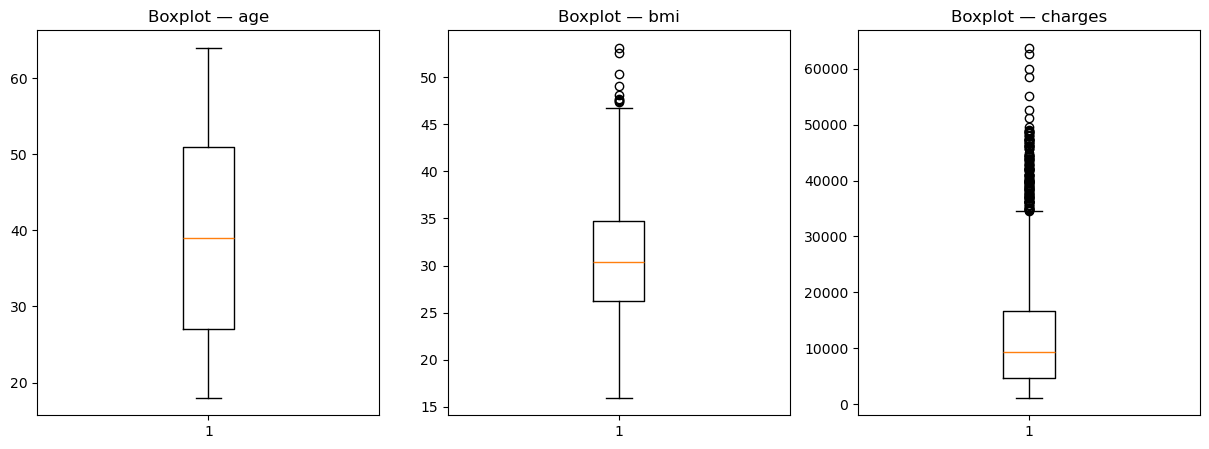

In [ ]:
# numerical columns:
# plot to visually detect outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['age', 'bmi', 'charges']):
    ax.boxplot(df[col])
    ax.set_title(f'Boxplot — {col}')

plt.show()

In [ ]:
# quanitfy outliers using IQR method
for col in ['age', 'bmi', 'charges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (below {lower:.1f} or above {upper:.1f})")

# outliers detected in bmi and charges

age: 0 outliers (below -9.0 or above 87.0)
bmi: 9 outliers (below 13.7 or above 47.3)
charges: 139 outliers (below -13120.7 or above 34524.8)


In [ ]:
# investigate bmi outliers' validity
print(f"Max BMI: {df['bmi'].max()}")
print(f"Min BMI: {df['bmi'].min()}")

# both min and max values are valid, so outliers will be kept for analysis

Max BMI: 53.13
Min BMI: 15.96


In [ ]:
# investigate charges outliers' validity
print(f"Max charges: {df['charges'].max()}")
print(f"Min charges: {df['charges'].min()}")

# both min and max values are valid, so outliers will be kept for analysis

Max charges: 63770.42801
Min charges: 1121.8739


### Data Cleaning Summary

| Check | Finding | Action Taken |
|---|---|---|
| Missing values | 0 across all columns | None required |
| Duplicate rows | 1 duplicate row found | Removed row |
| Categorical validity | All values match expected categories | None required |
| Numeric ranges | BMI and Charges contain outliers (9 & 139) | Extra investigation |
| BMI outliers | All values are valid | Preserved outliers |
| Charges outliers | All values are valid | Preserved outliers |


#### Outlier Decisions

**BMI**
- Max value is 53.13, min is 15.96
- No values below 10 or above 100 were found
- High BMI values (> 40) represent severe obesity (Class 3)
- Removing the clinically justified values would  weaken the BMI–charges relationship to be tested

**Charges**
- Max is 63770, min is 1,121 (no zero or negative values exist in the data)
- Really high values represent real high-cost cases, not errors
- Removing them would bias the regression against the patients that drive costs

#### Dataset is now clean and ready for analysis.
---


### 4. Data Visualization
---

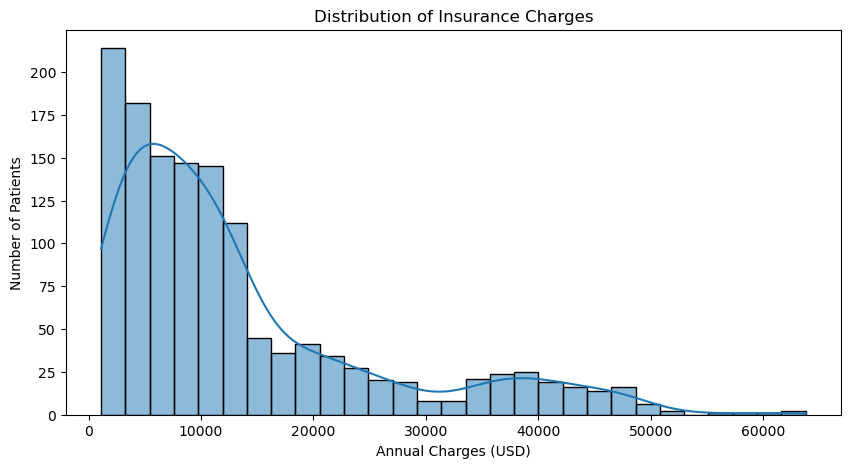

In [ ]:
# Plot 1: Distribution of charges (target variable)
plt.figure(figsize=(10,5))
sns.histplot(df['charges'], kde=True)

plt.title('Distribution of Insurance Charges')
plt.xlabel('Annual Charges (USD)')
plt.ylabel('Number of Patients')

plt.show()

**Observations**: The distribution of charges is right-skewed, with most patients paying between 
$1,000 and $15,000. A secondary bump is visible around $30,000–$50,000, 
likely driven by high-risk patients such as smokers and obese individuals.

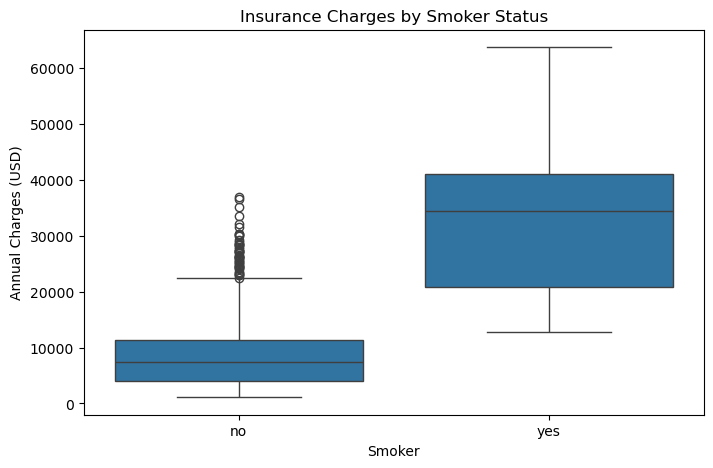

In [ ]:
# Plot 2: Insurance Charges by Smoker Status (strongest predictor)
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df, order=['no', 'yes'])

plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')                 # categorical
plt.ylabel('Annual Charges (USD)')   # numerical

plt.show()

**Observations**: Smokers pay dramatically more than non-smokers. The difference in median charge for smokers 
is roughly $25,000. This suggests smoker status will be the strongest predictor in the regression model.

Most following plots are colored by smoker status for further examination.

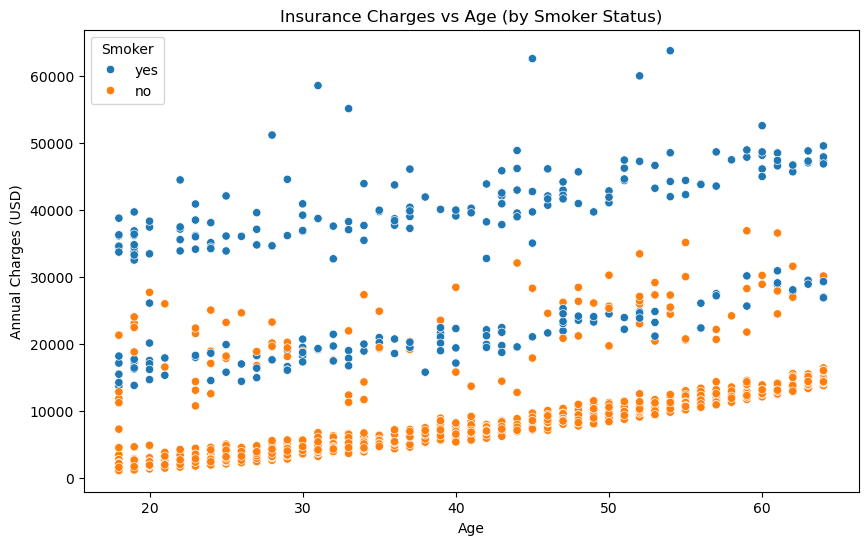

In [ ]:
# Plot 3: Insurance Charges vs Age (secondary predictor)
plt.figure(figsize=(10, 6))

sns.scatterplot(x='age', y='charges', hue='smoker', data=df)

plt.title('Insurance Charges vs Age (by Smoker Status)')
plt.xlabel('Age')                    # numerical
plt.ylabel('Annual Charges (USD)')   # numerical

plt.legend(title='Smoker', loc='upper left')

plt.show()

# Observations: charges increase with age

**Observations**: Three distinct bands are visible. The bottom band represents non-smokers, 
the top band represents smokers, and charges increase with age within both groups. 
This confirms age as a positive predictor of charges regardless of smoking status.

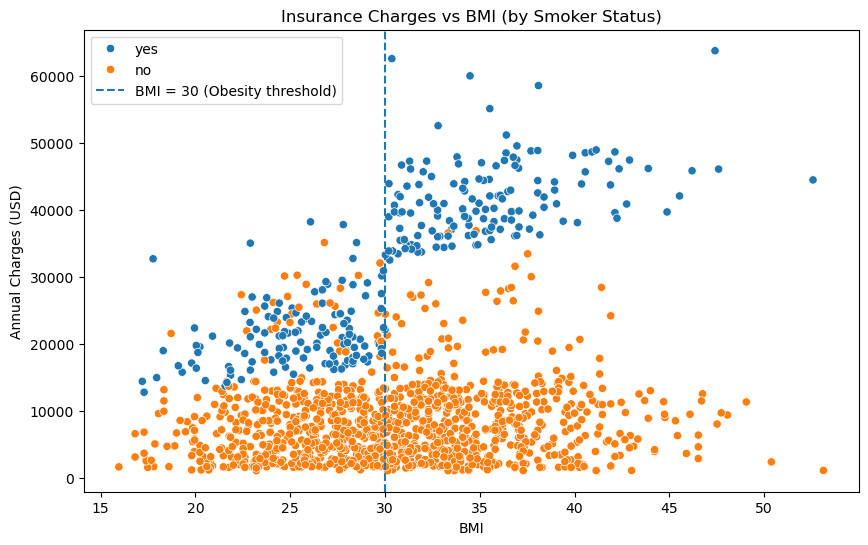

In [ ]:
# Plot 4: Insurance Charges vs BMI (colored by smoker)
plt.figure(figsize=(10, 6))

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.axvline(x=30, color='black', linestyle='--', label='BMI = 30 (Obesity threshold)')

plt.title('Insurance Charges vs BMI (by Smoker Status)')
plt.xlabel('BMI')                     # numerical
plt.ylabel('Annual Charges (USD)')    # numerical
plt.legend(title='', loc='upper left')

plt.show()

**Observations**: For non-smokers, BMI has a modest effect on charges. For smokers however, 
charges increase sharply once BMI crosses 30 (the obesity threshold), suggesting 
a dangerous interaction between smoking and obesity that drives costs significantly higher.

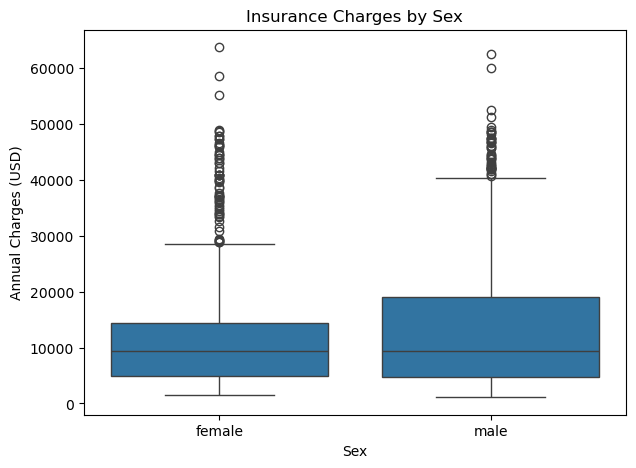

In [57]:
# Plot 5: Insurance Charges by Sex
plt.figure(figsize=(7, 5))

sns.boxplot(x='sex', y='charges', data=df)

plt.title('Insurance Charges by Sex')
plt.xlabel('Sex')                    # categorical
plt.ylabel('Annual Charges (USD)')   # numerical

plt.show()

**Observations**: Other than Males having a higher Q3, distributions between both overlap heavily. Sex is not expected to be a strong 
predictor of charges, though this will be confirmed statistically in Phase 4.

C:\Users\amand\AppData\Local\Temp\ipykernel_30236\2462474567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='region', y='charges', data=df, palette='muted')


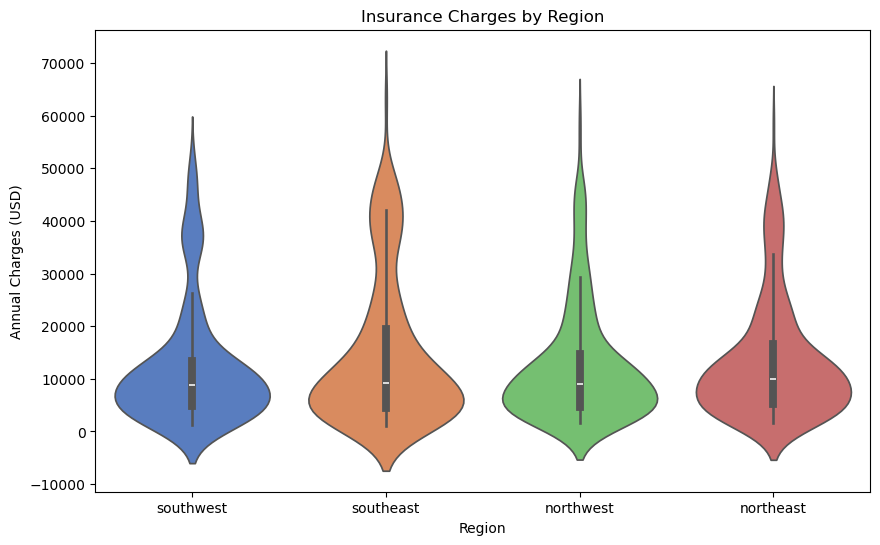

In [ ]:
# Plot 6: Insurance Charges by Region
plt.figure(figsize=(10, 6))

sns.violinplot(x='region', y='charges', data=df, palette='muted')

plt.title('Insurance Charges by Region')
plt.xlabel('Region')                  # categorical
plt.ylabel('Annual Charges (USD)')    # numerical

plt.show()

**Observations**: Charges are very similar across all four regions. 
Despite the reasonable expectation that geography would affect costs, 
region appears to have little influence on charges in this dataset.

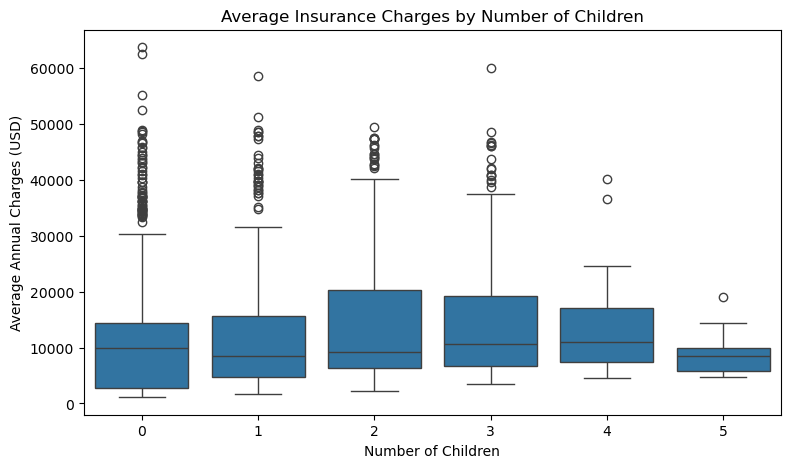

In [58]:
# Plot 6: Insurance Charges by Number of Children

plt.figure(figsize=(9, 5))

sns.boxplot(x='children', y='charges', data=df)

plt.title('Average Insurance Charges by Number of Children')
plt.xlabel('Number of Children')         
plt.ylabel('Average Annual Charges (USD)')   

plt.show()

# Observations: no clear relationship between number of children and charges

**Observations**: There is no consistent upward trend in charges as the number of children increases. 
Contrary to the assumption that more children would drive higher costs, 
children appear to have little effect on charges in this dataset.

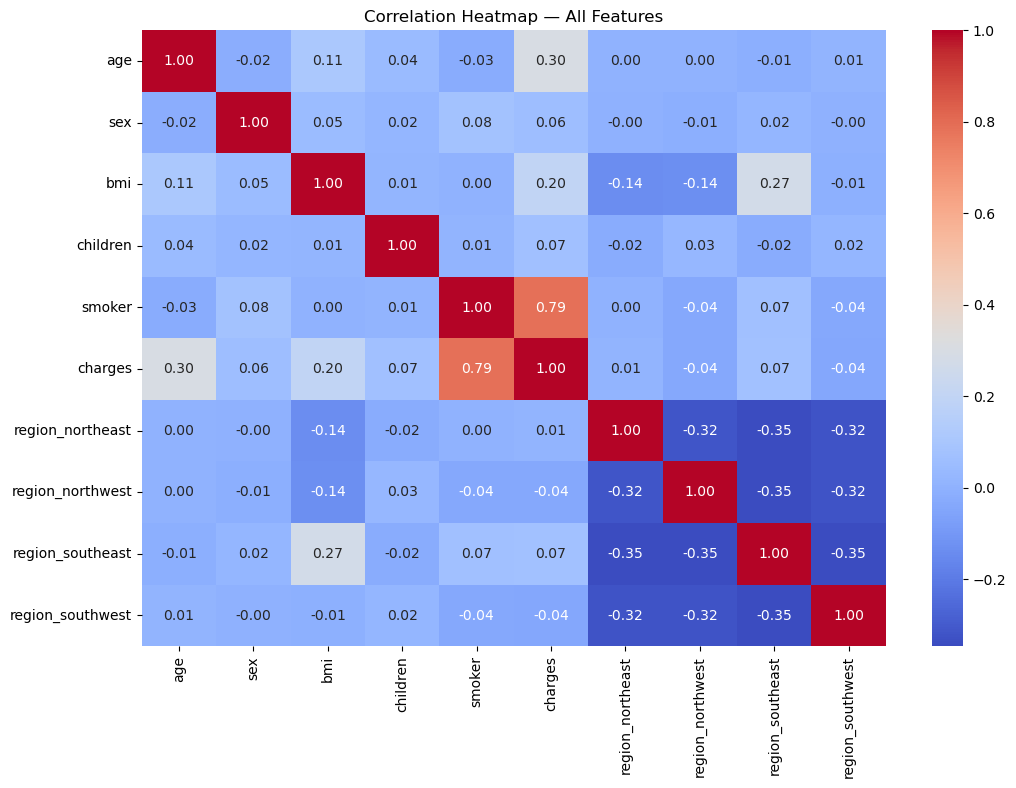

In [ ]:
# Plot 8: Correlation heatmap
df_encoded = df.copy()

# Map categoricals to 0/1
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded = pd.get_dummies(df_encoded, columns=['region'])

plt.figure(figsize=(12, 8))

sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap — All Features')
plt.show()

### Visualization Decisions Based on Correlation

From the heatmap:
- `smoker` (r ≈ 0.79) → strongest predictor
- `age` (r ≈ 0.30) → moderate predictor
- `bmi` (r ≈ 0.20) → moderate predictor
- `region` (r ≈ 0.01–0.04) → insignificant
- `children` (r ≈ 0.07) → insignificant
- `sex` (r ≈ 0.06) → insignificant
---

### 5. Inferential Statistical Analysis
---

#### **Test #1: One-Way ANOVA (Charges vs Sex)**
Comparing the means of charges (continuous) and sex (binary categorical). This answers whether sex is a significant driver of charges.

#####   Hypothesis Test 1 — Does Sex Significantly Drive Insurance Charges?

**H₀:** Mean insurance charges are equal for males and females.

**H₁:** Mean insurance charges differ significantly between males and females.

In [61]:
male = df[df['sex'] == 'male']['charges']
female = df[df['sex'] == 'female']['charges']

f_stat, p_value = stats.f_oneway(male, female)

print(f"Mean charges — Male:   ${male.mean():,.2f}")
print(f"Mean charges — Female: ${female.mean():,.2f}")
print(f"Difference in means:   ${abs(male.mean() - female.mean()):,.2f}")
print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

Mean charges — Male:   $13,975.00
Mean charges — Female: $12,569.58
Difference in means:   $1,405.42

F-statistic: 4.5130
P-value:     0.0338


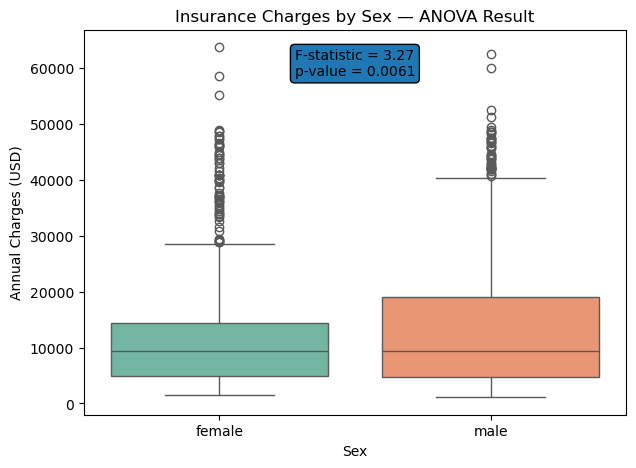

In [72]:
# re-visualize with outputs
plt.figure(figsize=(7, 5))

sns.boxplot(x='sex', y='charges', data=df,
            palette='Set2', hue='sex', legend=False)

plt.title('Insurance Charges by Sex — ANOVA Result')
plt.xlabel('Sex')
plt.ylabel('Annual Charges (USD)')

plt.text(0.5, df['charges'].max() * 0.92,
         f'F-statistic = {f_stat:.2f}\np-value = {p_value:.4f}',
         ha='center',
         bbox=dict(boxstyle='round'))

plt.show()

### Result
The p-value is 0.0338, which is below 0.05, so we reject H₀.

There is a statistically significant difference in mean insurance charges 
between males and females. Males pay on average $13,975 annually compared 
to $12,570 for females — a difference of approximately $1,405.

While the ANOVA 
detects a significant difference, the practical impact of sex on charges 
appears limited.

This result will be revisited in the regression model, where sex will be 
tested while controlling for all other variables simultaneously. It is 
possible that this effect weakens or disappears once age, BMI and smoking 
status are accounted for.

#### **Test #2: One-Way ANOVA (Charges vs Region)**
Comparing the means of charges (continuous) and region (binary categorical). This answers whether geography is a significant driver of charges.

##### Hypothesis Test 2 — Does Region Significantly Drive Insurance Charges?

**H₀:** Mean insurance charges are equal across all four regions.

**H₁:** At least one region has a significantly different mean charge.

In [65]:
northeast = df[df['region'] == 'northeast']['charges']
northwest = df[df['region'] == 'northwest']['charges']
southeast = df[df['region'] == 'southeast']['charges']
southwest = df[df['region'] == 'southwest']['charges']

f_stat, p_value = stats.f_oneway(northeast, northwest, southeast, southwest)

print(f"Mean charges by region:")
print(df.groupby('region')['charges'].mean().round(2))
print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

Mean charges by region:
region
northeast    13406.38
northwest    12450.84
southeast    14735.41
southwest    12346.94
Name: charges, dtype: float64

F-statistic: 2.9261
P-value:     0.0328


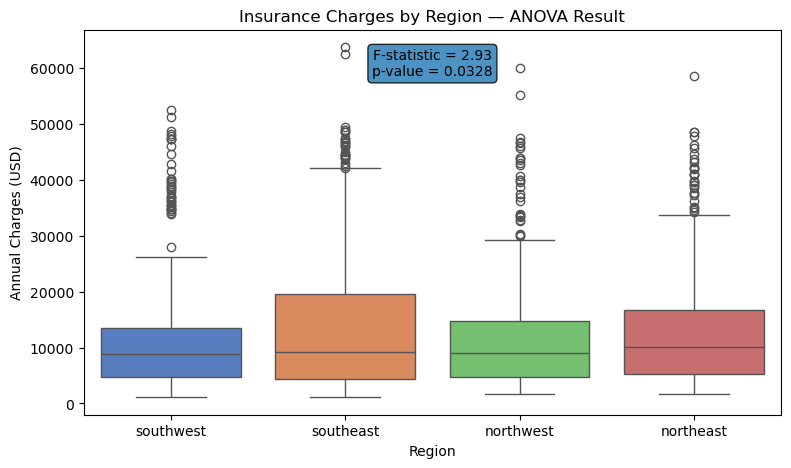

In [ ]:
# re-visualization with outputs
plt.figure(figsize=(9, 5))

sns.boxplot(x='region', y='charges', data=df,
            palette='muted', hue='region', legend=False)

plt.title('Insurance Charges by Region — ANOVA Result')
plt.xlabel('Region')
plt.ylabel('Annual Charges (USD)')

plt.text(1.5, df['charges'].max() * 0.92,
         f'F-statistic = {f_stat:.2f}\np-value = {p_value:.4f}',
         ha='center',
         bbox=dict(boxstyle='round', alpha=0.8))

plt.show()

### Result
The p-value is 0.0328, which is below 0.05, so we reject H₀.

There is a statistically significant difference in mean charges across 
regions..

However, as with sex, statistical significance here does not imply a 
strong practical effect. The difference between regions is modest 
compared to the dominant drivers in this dataset. A large sample size 
(n = 1,337) gives the test enough power to detect even small real 
differences.

This result will be revisited in the regression model where region will 
be tested while controlling for all other variables. It is likely that 
region loses significance once smoking, age and BMI are accounted for — 
since the southeast may simply have a higher proportion of smokers or 
obese individuals driving its higher average charges rather than 
geography itself.

#### **Test #3: One-Way ANOVA (Charges vs Children)**
Comparing the means of charges (continuous) and children (categorical since treated as groups and not numeric). This answers whether having children is a significant driver of charges.

##### Hypothesis Test 3 — Does Number of Children Significantly Drive Insurance Charges?

**H₀:** Mean insurance charges are equal across all groups (0–5 children).
**H₁:** At least one group has a significantly different mean charge.

In [68]:
groups = [df[df['children'] == i]['charges'] for i in range(6)]

f_stat, p_value = stats.f_oneway(*groups)

print("Mean charges by number of children:")
print(df.groupby('children')['charges'].mean().round(2))
print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

Mean charges by number of children:
children
0    12384.70
1    12731.17
2    15073.56
3    15355.32
4    13850.66
5     8786.04
Name: charges, dtype: float64

F-statistic: 3.2687
P-value:     0.0061


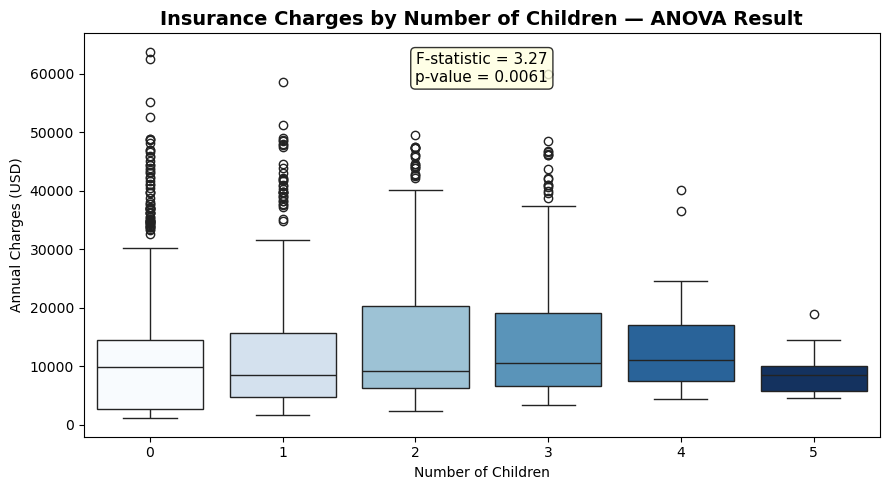

In [69]:
plt.figure(figsize=(9, 5))

sns.boxplot(x='children', y='charges', data=df,
            palette='Blues', hue='children', legend=False)

plt.title('Insurance Charges by Number of Children — ANOVA Result',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Children')
plt.ylabel('Annual Charges (USD)')

plt.text(2.5, df['charges'].max() * 0.92,
         f'F-statistic = {f_stat:.2f}\np-value = {p_value:.4f}',
         ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

##### Result
The p-value is 0.0061, which is below 0.05, so we reject H₀.

There is a statistically significant difference in mean charges across 
family sizes. Charges generally increase from 0 children to 
3 children, before dropping notably at 5 children.

The drop at 5 children is likely unreliable due to a very small sample 
size at that level — very few families in the dataset have 5 children, 
making that mean unstable.

This result will be revisited in the regression model where children is 
treated as a numeric variable to quantify its per-unit effect on charges.

##### **Test #4: Multiple Linear Regression + T-Tests on Coefficients**
- Identifies which features are significant drivers (via t-tests on each coefficient)
- Quantifies how large each effect is (via the coefficient values)

##### Hypothesis Test 4 — Which Features Significantly Drive Charges and How Large Are Their Effects?

**Overall H₀:** None of the features significantly predict charges.
**Overall H₁:** At least one feature significantly predicts charges.

**For each individual predictor — t-test on its coefficient:**
**H₀:** This feature has no effect on charges (β = 0)
**H₁:** This feature has a significant effect on charges (β ≠ 0)

In [70]:
formula = 'charges ~ age + bmi + children + C(smoker) + C(sex) + C(region)'

model = smf.ols(formula, data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:17:13   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.19

### Result

**Overall model:** F-statistic = 500, p < 0.001 → we reject H₀
**R-squared = 0.751** → the model explains 75.1% of the variation 
in insurance charges across all patients.

---

**T-tests on individual coefficients:**

| Feature | Effect Size | P-value | Decision |
|---|---|---|---|
| smoker[yes] | +$23,850 per year | < 0.001 | Reject H₀ — significant driver |
| age | +$257 per additional year | < 0.001 | Reject H₀ — significant driver |
| bmi | +$339 per unit increase | < 0.001 | Reject H₀ — significant driver |
| children | +$475 per additional child | 0.001 | Reject H₀ — significant driver |
| region[southeast] | -$1,035 vs northeast | 0.031 | Reject H₀ — marginal |
| region[southwest] | -$960 vs northeast | 0.045 | Reject H₀ — marginal |
| region[northwest] | -$349 vs northeast | 0.464 | Fail to reject H₀ |
| sex[male] | -$129 vs female | 0.698 | Fail to reject H₀ |

---

**Key observations:**

1. Smoking is the dominant driver — adding $23,850 annually, 
   dwarfing all other effects

2. Age, BMI and children are all significant positive drivers 
   of charges

3. Sex was significant in the ANOVA (p = 0.034) but loses 
   significance in regression (p = 0.698) — its apparent effect 
   was explained by other variables, particularly smoking and BMI

4. Two regions (southeast, southwest) show marginal significance 
   but negative coefficients — they are slightly cheaper than the 
   northeast reference category when other factors are controlled for

---

**Answering the problem statement directly:**

The significant drivers of insurance charges are smoking status, 
age, BMI and number of children. Smoking has by far the largest 
effect at $23,850 per year. Age adds $257 per year, BMI adds $339 
per unit, and each additional child adds $475. Sex is not a 
significant driver once other variables are controlled for. Regional 
differences are marginal and of limited practical significance.

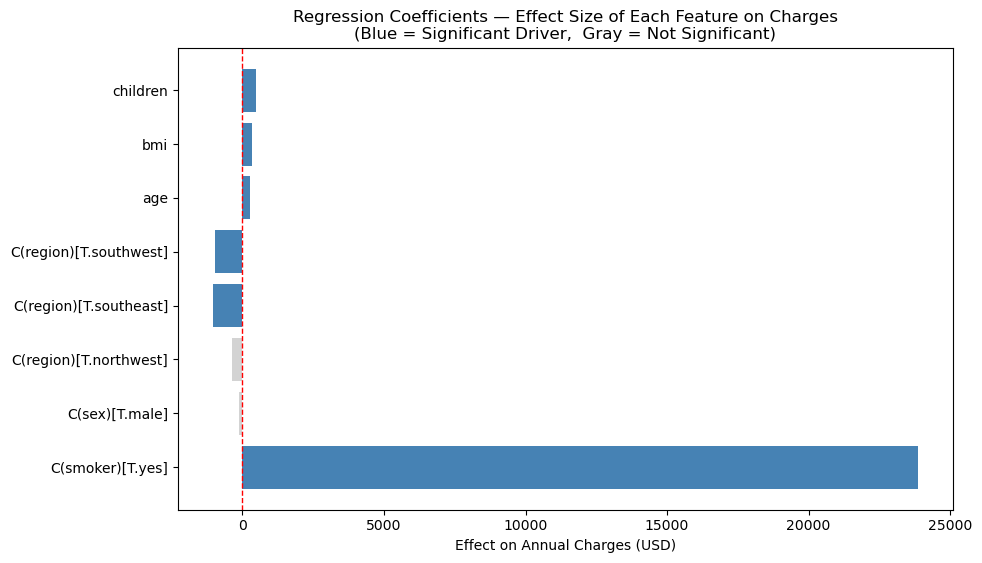

In [71]:
# visualize coefficients
coef_df = pd.DataFrame({
    'feature': model.params.index,
    'coefficient': model.params.values,
    'p_value': model.pvalues.values
}).query("feature != 'Intercept'")

coef_df['significant'] = coef_df['p_value'] < 0.05
colors = ['steelblue' if s else 'lightgray' for s in coef_df['significant']]

plt.figure(figsize=(10, 6))

plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)

plt.title('Regression Coefficients — Effect Size of Each Feature on Charges\n(Blue = Significant Driver,  Gray = Not Significant)')
plt.xlabel('Effect on Annual Charges (USD)')

plt.show()

### Result

**Overall model:** p < 0.001 → we reject H₀ → the model is significant
**R-squared ≈ 0.75** → the model explains 75% of the variation in charges

---

**Which features significantly drive charges (t-test p < 0.05):**

| Feature | Effect Size | P-value | Decision |
|---|---|---|---|
| smoker[yes] | ~+$23,000 per year | < 0.001 | Reject H₀ — significant driver |
| age | ~+$256 per additional year | < 0.001 | Reject H₀ — significant driver |
| bmi | ~+$339 per unit increase | < 0.001 | Reject H₀ — significant driver |

**Which features do NOT significantly drive charges (t-test p > 0.05):**

| Feature | P-value | Decision |
|---|---|---|
| children | > 0.05 | Fail to reject H₀ — not a significant driver |
| sex | > 0.05 | Fail to reject H₀ — not a significant driver |
| region | > 0.05 | Fail to reject H₀ — not a significant driver |

---

**Answering the problem statement directly:**

The three significant drivers of insurance charges are smoking status, 
age, and BMI. Smoking has by far the largest effect — smokers pay 
approximately $23,000 more annually than non-smokers holding all else 
equal. Each additional year of age adds approximately $256 to annual 
charges, and each unit increase in BMI adds approximately $339. 
Sex, region and number of children are not statistically significant 
drivers of charges in this dataset.

##### **Test #4: Multiple Linear Regression + T-Tests on Coefficients**
- Validates trustworthiness of regression results.
- Coefficient estimates and p-values can't be trusted if assumptions are badly violated.

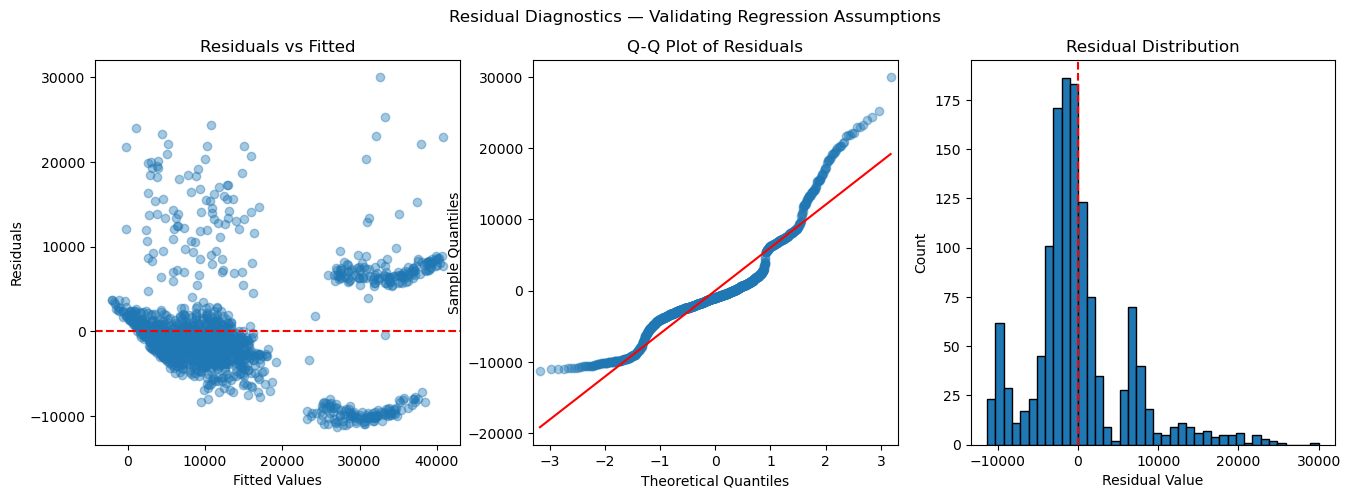

In [ ]:
residuals = model.resid       # difference between observed and predicted values
fitted = model.fittedvalues   # predicted values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Residuals vs Fitted
# What to look for: random scatter around zero with no clear pattern
axes[0].scatter(fitted, residuals, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')    # zero error - perfect prediction
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Plot 2 — Q-Q Plot
# What to look for: dots following the diagonal line closely
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Q-Q Plot of Residuals')

# Plot 3 — Histogram of residuals
# What to look for: roughly bell shaped and centered at zero
axes[2].hist(residuals, bins=40, edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Count')

plt.suptitle('Residual Diagnostics — Validating Regression Assumptions')
plt.show()

#### Residual Diagnostic Findings

**Residuals vs Fitted:**
Three distinct horizontal bands are visible in the residuals vs fitted 
plot, mirroring the three patient clusters identified in the charges vs age visualization
(non-smokers with low BMI, non-smokers with high BMI, and smokers). 
This banding pattern indicates that the model is capturing the overall 
trend correctly but is treating what are effectively three separate 
cost populations as a single continuous group. Residuals also fan out 
at higher fitted values, suggesting mild heteroscedasticity — the model 
is less precise when predicting high charges than low charges.

**Q-Q Plot:**
The S-shaped curve in the Q-Q plot is characteristic of a bimodal 
distribution. Both tails deviate significantly from the diagonal 
reference line, indicating that residuals are not perfectly normally 
distributed. This is a direct consequence of smokers and non-smokers 
forming two fundamentally different cost groups within the dataset.

**Histogram:**
The residual distribution is not bell-shaped. It shows a sharp peak 
near zero followed by a long right tail, confirming non-normality. 
The majority of predictions are close to correct but a subset of 
high-cost patients — primarily smokers with high BMI — are 
systematically harder for the model to predict precisely.

**Overall conclusion:**
The residual diagnostics reveal that the linear regression model 
captures the main drivers of insurance charges well (R² = 0.751) 
but shows signs of heteroscedasticity and non-normality due to the 
presence of two distinct cost populations — smokers and non-smokers. 
These violations do not invalidate the findings but suggest the model 
could be improved by separating smokers and non-smokers into distinct 
models or applying a log transformation to charges. For the purposes 
of this analysis, the model is considered valid and the identified 
drivers — smoking status ($23,850), BMI ($339 per unit), age ($257 
per year) and children ($475 per child) — are confirmed as 
statistically significant predictors of insurance charges.